# Лабораторна робота №3: Візуалізація даних
**Виконав:** студент групи ФБ-41 Волошин Дмитро
**Датасет:** UCI Automobile Dataset (Imports 1985)

### Мета роботи:
Ознайомитися з методами попередньої обробки даних (Data Cleaning) та сучасними бібліотеками візуалізації в Python (`matplotlib`, `seaborn`). Навчитися відображати багатовимірні зв'язки між ознаками відповідно до концепцій ефективного візуального аналізу.

In [1]:
!pip install seaborn matplotlib pandas numpy


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

df = pd.read_csv(url, names=columns)
print(f"Розмірність датасету: {df.shape}")
df.head()

Розмірність датасету: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Етап 1: Очищення даних (Data Cleaning)
У цьому датасеті пропущені значення позначені як `?`. Нам потрібно:
1. Замінити `?` на стандартні для Python `NaN` (`np.nan`).
2. Привести стовпчики до правильних типів даних (оскільки через знаки `?` числові стовпчики зчиталися як текстові `object`).
3. Обробити пропущені значення (заповнити медіаною для числових або модою для категоріальних).

In [3]:
df.replace('?', np.nan, inplace=True)

print("Кількість пропусків у стовпчиках:")
print(df.isnull().sum()[df.isnull().sum() > 0])

numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print("\nПісля очищення (загальна кількість пропусків):")
print(df.isnull().sum().sum())

Кількість пропусків у стовпчиках:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Після очищення (загальна кількість пропусків):
0


## Етап 2: Візуалізація даних

### Графік 1: Залежність між двома числовими атрибутами (Scatter Plot)
Покажемо, як об'єм двигуна (`engine-size`) впливає на ціну автомобіля (`price`).

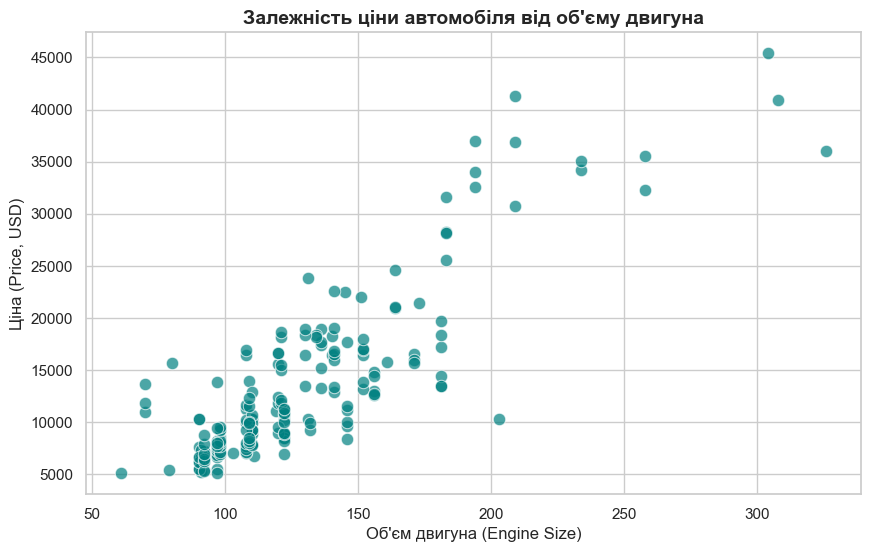

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="engine-size", y="price", alpha=0.7, color="teal", edgecolor="w", s=80)
plt.title("Залежність ціни автомобіля від об'єму двигуна", fontsize=14, fontweight='bold')
plt.xlabel("Об'єм двигуна (Engine Size)", fontsize=12)
plt.ylabel("Ціна (Price, USD)", fontsize=12)
plt.show()

### Графік 2: Тренд залежності показників (Line Plot з агрегацією)
Покажемо зміну середньої вартості автомобіля залежно від його потужності (`horsepower`). Використовуємо лінійний графік з автоматичним обчисленням довірчого інтервалу (shadow area).

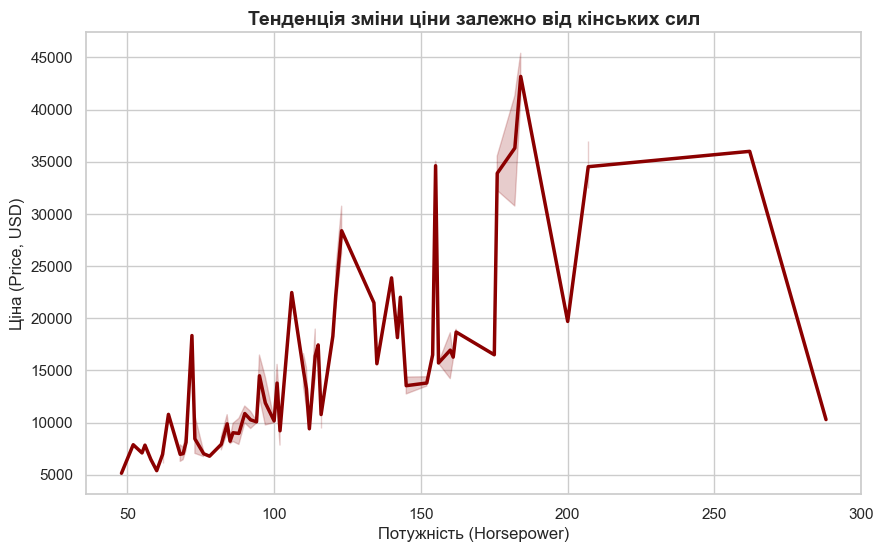

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="horsepower", y="price", color="darkred", linewidth=2.5)
plt.title("Тенденція зміни ціни залежно від кінських сил", fontsize=14, fontweight='bold')
plt.xlabel("Потужність (Horsepower)", fontsize=12)
plt.ylabel("Ціна (Price, USD)", fontsize=12)
plt.show()

### Графік 3: Гістограма з 5 фіксованими діапазонами
Поділимо ціну автомобілів на 5 конкретних діапазонів (кастомні біни) для аналізу цінових сегментів: 
1. Бюджетні (5,000 – 10,000)
2. Економ (10,000 – 20,000)
3. Мідл (20,000 – 30,000)
4. Преміум (30,000 – 40,000)
5. Люкс (40,000 – 55,000)

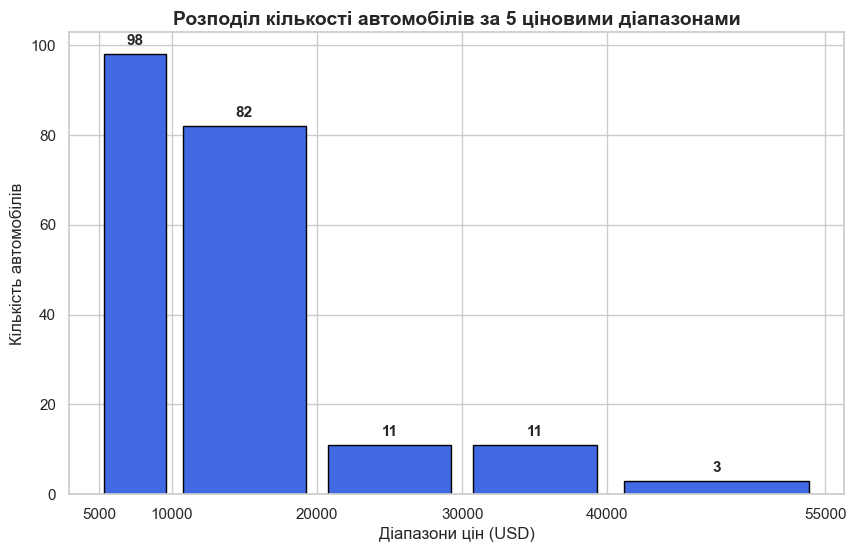

In [6]:
plt.figure(figsize=(10, 6))

custom_bins = [5000, 10000, 20000, 30000, 40000, 55000]

n, bins, patches = plt.hist(df['price'], bins=custom_bins, color='royalblue', edgecolor='black', rwidth=0.85)

for i in range(len(n)):
    plt.text(bins[i] + (bins[i+1]-bins[i])/2, n[i] + 2, str(int(n[i])), ha='center', fontsize=11, fontweight='bold')

plt.title("Розподіл кількості автомобілів за 5 ціновими діапазонами", fontsize=14, fontweight='bold')
plt.xlabel("Діапазони цін (USD)", fontsize=12)
plt.ylabel("Кількість автомобілів", fontsize=12)
plt.xticks(custom_bins)
plt.show()

### Графік 4: 3D Візуалізація у 2D просторі (Згідно зі статтею Medium: 3-Dimension Visuals)
Один із найкращих способів показати 3 виміри без побудови заплутаних 3D-осей — це використання параметра **Hue (Кольору)** для категоріальної ознаки на Scatter Plot.
* **X:** Потужність (`horsepower`)
* **Y:** Ціна (`price`)
* **Hue (3-й вимір):** Тип приводу (`drive-wheels` — rwd, fwd, 4wd)

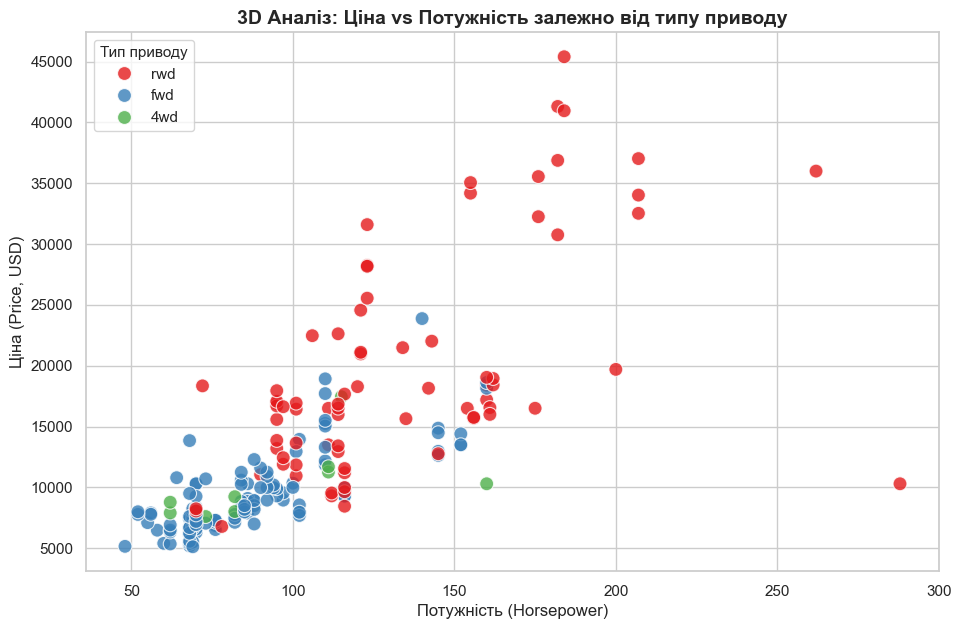

In [7]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x="horsepower", y="price", hue="drive-wheels", palette="Set1", s=100, alpha=0.8)
plt.title("3D Аналіз: Ціна vs Потужність залежно від типу приводу", fontsize=14, fontweight='bold')
plt.xlabel("Потужність (Horsepower)", fontsize=12)
plt.ylabel("Ціна (Price, USD)", fontsize=12)
plt.legend(title="Тип приводу", title_fontsize='11', loc='upper left')
plt.show()

### Графік 5: 4D Візуалізація (Згідно зі статтею Medium: 4-Dimension Visuals)
Додаємо 4-й вимір за допомогою параметра **Size (Розміру точок)**.
* **X:** Об'єм двигуна (`engine-size`)
* **Y:** Ціна (`price`)
* **Hue (3-й вимір):** Тип палива (`fuel-type` — gas/diesel)
* **Size (4-й вимір):** Вага автомобіля (`curb-weight`)

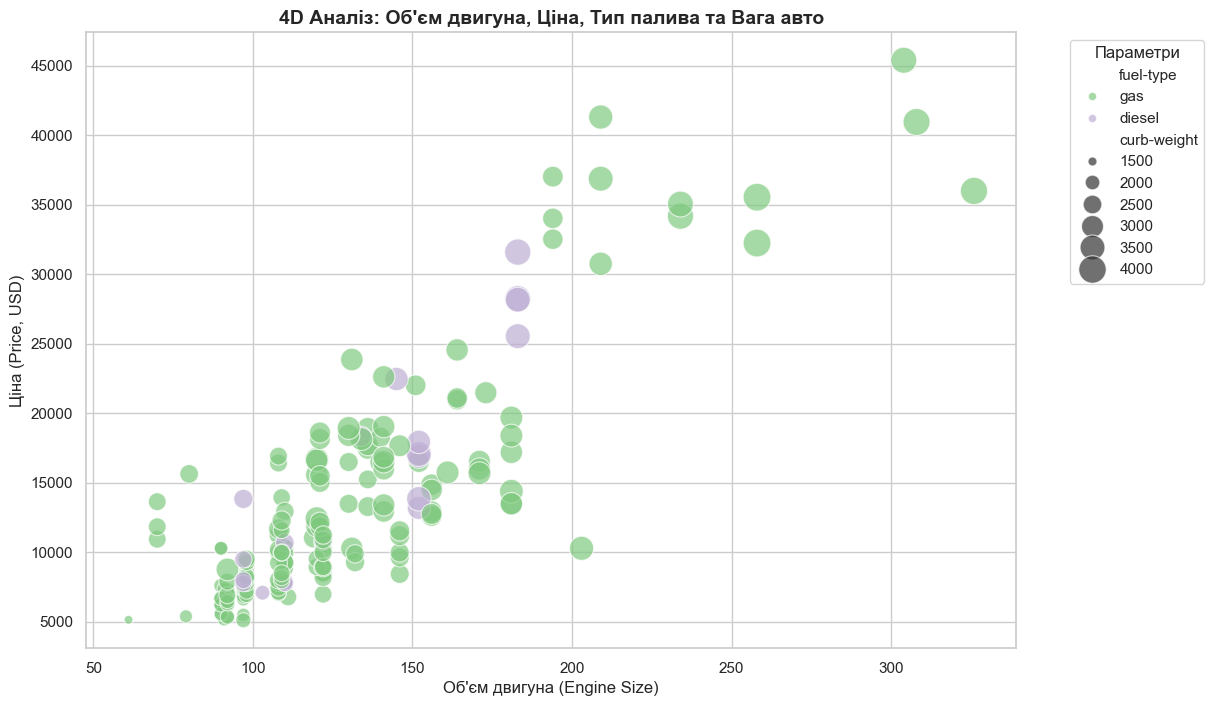

In [8]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x="engine-size", 
    y="price", 
    hue="fuel-type", 
    size="curb-weight", 
    sizes=(40, 400), 
    palette="Accent", 
    alpha=0.7
)
plt.title("4D Аналіз: Об'єм двигуна, Ціна, Тип палива та Вага авто", fontsize=14, fontweight='bold')
plt.xlabel("Об'єм двигуна (Engine Size)", fontsize=12)
plt.ylabel("Ціна (Price, USD)", fontsize=12)
plt.legend(title="Параметри", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Графік 6: 5D Візуалізація за допомогою Фасетів (Згідно зі статтею Medium: 5-Dimension Visuals)
Щоб додати 5-й вимір, використовуємо концепцію **Faceting (розбиття на підграфіки/колонки)** за допомогою інструменту `sns.relplot`.
* **X:** Потужність (`horsepower`)
* **Y:** Ціна (`price`)
* **Hue (3-й вимір):** Тип палива (`fuel-type`)
* **Size (4-й вимір):** Об'єм двигуна (`engine-size`)
* **Col / Facet (5-й вимір):** Тип надуву (`aspiration` — std / turbo)

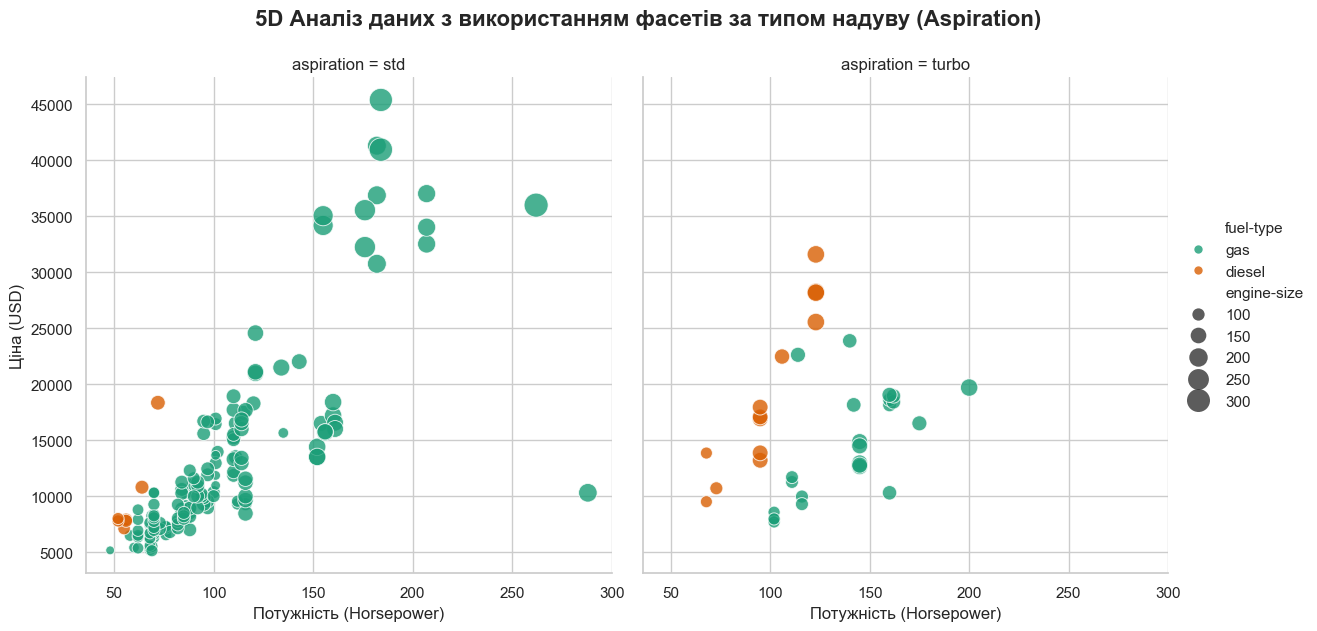

In [9]:
g = sns.relplot(
    data=df, 
    x="horsepower", 
    y="price", 
    hue="fuel-type", 
    size="engine-size", 
    col="aspiration", 
    palette="Dark2", 
    sizes=(40, 300), 
    alpha=0.8, 
    height=6, 
    aspect=1
)
g.fig.suptitle("5D Аналіз даних з використанням фасетів за типом надуву (Aspiration)", y=1.05, fontsize=16, fontweight='bold')
g.set_axis_labels("Потужність (Horsepower)", "Ціна (USD)")
plt.show()

### Графік 7: Додатковий аналітичний графік — Матриця кореляції (Heatmap)
Побудуємо теплову карту кореляції, щоб побачити лінійні взаємозв'язки між усіма числовими стовпчиками датасету.

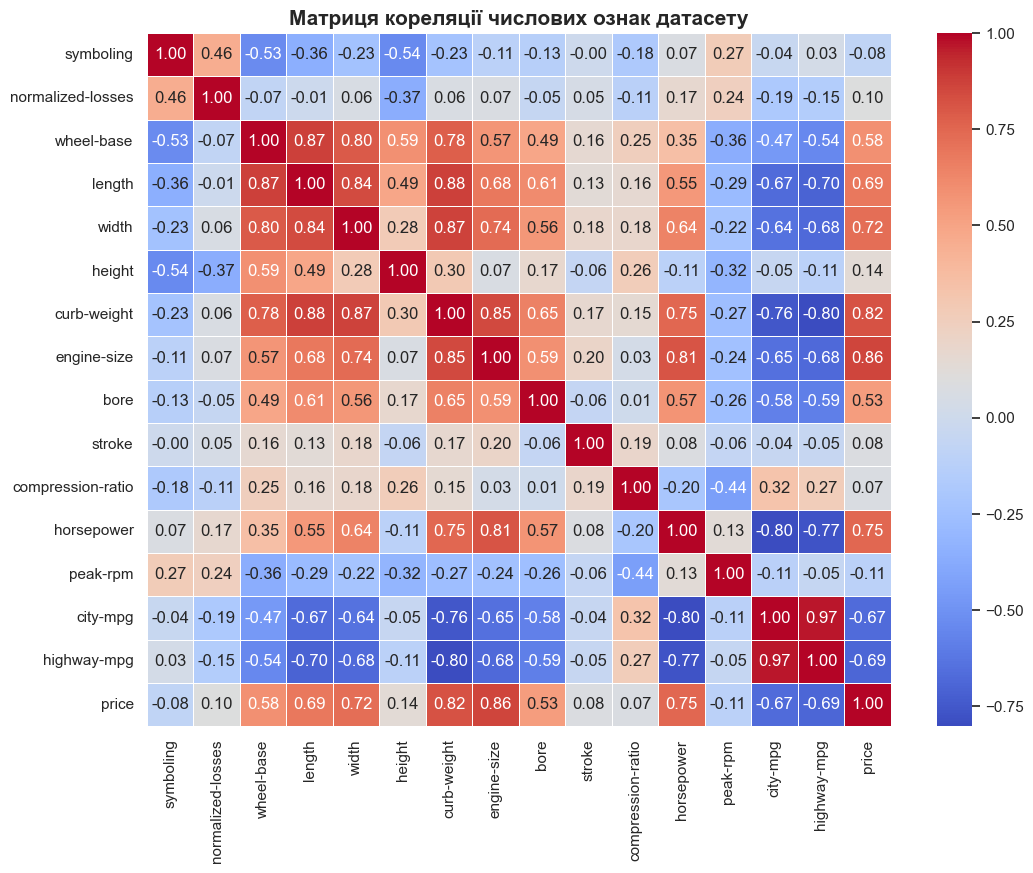

In [10]:
plt.figure(figsize=(12, 9))

selected_numeric = df[["symboling", "normalized-losses", "wheel-base", "length", 
                       "width", "height", "curb-weight", "engine-size", 
                       "bore", "stroke", "compression-ratio", "horsepower", 
                       "peak-rpm", "city-mpg", "highway-mpg", "price"]]

corr_matrix = selected_numeric.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Матриця кореляції числових ознак датасету", fontsize=15, fontweight='bold')
plt.show()

### Графік 8: Додатковий аналітичний графік — Розподіл цін за типами кузова (Boxplot)
Boxplot чудово демонструє медіану, квартилі та наявність аномальних викидів ціни для кожного типу кузова.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6464\3773468689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="body-style", y="price", palette="Pastel1")


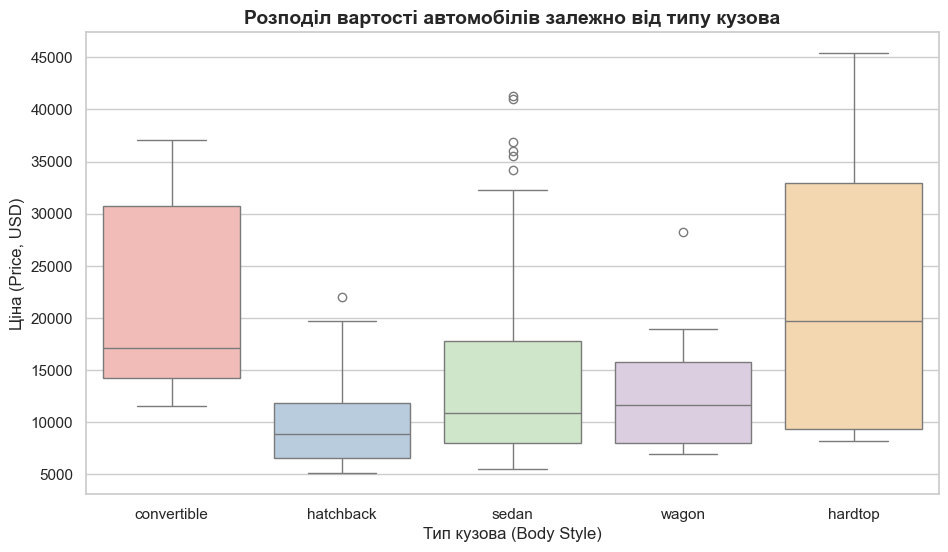

In [11]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="body-style", y="price", palette="Pastel1")
plt.title("Розподіл вартості автомобілів залежно від типу кузова", fontsize=14, fontweight='bold')
plt.xlabel("Тип кузова (Body Style)", fontsize=12)
plt.ylabel("Ціна (Price, USD)", fontsize=12)
plt.show()

## Висновки по роботі:
1. **Data Cleaning:** Пропуски у вигляді знаків `?` було успішно локалізовано, трансформовано у типи `float64`/`int64` та імпутовано за допомогою стійкої до викидів медіани.
2. **Аналіз залежностей:** Виявлено сильну пряму лінійну кореляцію між об'ємом двигуна (`engine-size`), кінськими силами (`horsepower`) та ціною (`price`). Тобто чим потужніше авто, тим воно дорожче.
3. **Багатовимірний аналіз:** Завдяки використанню методів візуалізації n-вимірних просторів (через властивості `hue`, `size` та `col` у Seaborn), вдалося з'ясувати, що дорогі та потужні автомобілі найчастіше мають задній привід (`rwd`), більшу вагу (`curb-weight`) та оснащені турбонаддувом (`turbo`).